# PantryPlate — Week 1 Walkthrough

**For team members joining at the start of Week 2.**

This notebook is a runnable tour of everything built in Week 1 of PantryPlate (the data pipeline, popularity baseline, evaluation metrics, and the numbers behind our locked decisions). Read top-to-bottom, run any cell to inspect, and you'll come out understanding the foundation Week 2 builds on.

**What this notebook is *not*:**
- *Not* the deep EDA — that lives in [`notebooks/week1_eda.ipynb`](week1_eda.ipynb) (feasibility analysis per project pillar, plots, verdicts)
- *Not* the decision register — that lives in [`docs/data_decisions.md`](../docs/data_decisions.md) (11 locked decisions with evidence)
- *Not* the progress note — that lives in [`docs/week1_progress.md`](../docs/week1_progress.md) (what got built, what's outstanding)

**What it IS:**
- A code-and-output walkthrough of how to *use* the Week 1 modules
- The numbers you should trust as a starting point
- The conventions every Week 2 model needs to follow

## 0. Setup

Run this once. It pins the notebook's working directory to the project root and imports the modules built in Week 1.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pin cwd to project root so 'data/raw/...' paths resolve
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))

from src.data.loader import (
    load_recipes,
    load_interactions,
    filter_active_users,
    time_based_split,
    POSITIVE_THRESHOLD,
)
from src.data.ingredients import NUTRITION_FIELDS
from src.models.popularity import PopularityRecommender
from src.eval.metrics import recall_at_k, ndcg_at_k, mrr

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
print("Setup complete.")
print(f"Working dir: {Path.cwd()}")
print(f"POSITIVE_THRESHOLD = {POSITIVE_THRESHOLD} (4+ stars counts as positive)")

Setup complete.
Working dir: /Users/ikhyvicky/Documents/MITB_stuff/CS608Project2
POSITIVE_THRESHOLD = 4 (4+ stars counts as positive)


## 1. The data pipeline

Four functions do all the data loading and reshaping. Each one's behavior is captured by a `data_decisions.md` entry.

### `load_recipes()` — parses recipe metadata

Reads `data/raw/RAW_recipes.csv` and adds four parsed columns: `ingredients_parsed`, `tags_parsed`, `steps_parsed`, `nutrition_parsed`. Nutrition values are clipped by default (calories at 5000 kcal, PDV at 1000%) — see decision §9.

In [2]:
recipes = load_recipes()
print(f"Loaded {len(recipes):,} recipes\n")

# Show one fully-parsed recipe
sample = recipes.iloc[0]
print(f"Recipe ID: {sample['id']}")
print(f"Name: {sample['name']}")
print(f"Submitted: {sample['submitted'].date()}")
print(f"Ingredients ({len(sample['ingredients_parsed'])}): {sample['ingredients_parsed']}")
print(f"Tags (first 5 of {len(sample['tags_parsed'])}): {sample['tags_parsed'][:5]}")
print(f"Nutrition:")
for k, v in sample['nutrition_parsed'].items():
    print(f"  {k:<14} {v}")

Loaded 231,637 recipes

Recipe ID: 137739
Name: arriba   baked winter squash mexican style
Submitted: 2005-09-16
Ingredients (7): ['winter squash', 'mexican seasoning', 'mixed spice', 'honey', 'butter', 'olive oil', 'salt']
Tags (first 5 of 20): ['60-minutes-or-less', 'time-to-make', 'course', 'main-ingredient', 'cuisine']
Nutrition:
  calories       51.5
  fat_pdv        0.0
  sugar_pdv      13.0
  sodium_pdv     0.0
  protein_pdv    2.0
  satfat_pdv     0.0
  carbs_pdv      4.0


### `load_interactions()` — parses user-recipe ratings

Reads `data/raw/RAW_interactions.csv`. **Drops 0-star ratings by default** (decision §2 — these are "review left, no rating" entries that distort the rating signal).

In [3]:
interactions = load_interactions()
print(f"Loaded {len(interactions):,} interactions (after dropping zero-stars)")
print(f"  Original: 1,132,367; dropped 60,847 zero-stars (5.4%)\n")

print("Rating distribution:")
print(interactions['rating'].value_counts().sort_index())
print(f"\n4+ star (positive): {(interactions['rating'] >= 4).sum():,} "
      f"({(interactions['rating'] >= 4).mean():.1%})")

print(f"\nSample interaction:")
print(interactions.head(3).to_string(index=False))

Loaded 1,071,520 interactions (after dropping zero-stars)
  Original: 1,132,367; dropped 60,847 zero-stars (5.4%)

Rating distribution:
rating
1     12818
2     14123
3     40855
4    187360
5    816364
Name: count, dtype: int64

4+ star (positive): 1,003,724 (93.7%)

Sample interaction:
 user_id  recipe_id       date  rating                                                                                                                                                                                                        review
   38094      40893 2003-02-17       4                                                                    Great with a salad. Cooked on top of stove for 15 minutes.Added a shake of cayenne and a pinch of salt.  Used low fat sour cream.  Thanks.
 1293707      40893 2011-12-21       5 So simple, so delicious! Great for chilly fall evening. Should have doubled it ;)<br/><br/>Second time around, forgot the remaining cumin. We usually love cumin, but didn't notice th

### `filter_active_users()` — primary modeling cohort

Keeps only users with `>= min_ratings` (default 5). This is the **headline evaluation cohort** (decision §1) — 22K users with ≥5 ratings carry ~79% of the rating mass. Cold-start users (the other 200K+) are evaluated as a separate slice in Week 2+.

In [4]:
active = filter_active_users(interactions, min_ratings=5)
all_users = interactions['user_id'].nunique()
active_users = active['user_id'].nunique()

print(f"All users:        {all_users:>8,}")
print(f"Active (>=5):     {active_users:>8,}  ({active_users/all_users:.1%})")
print(f"Mass concentration: {len(active)/len(interactions):.1%} of interactions belong to active users")

All users:         196,098
Active (>=5):       22,018  (11.2%)
Mass concentration: 78.9% of interactions belong to active users


### `time_based_split()` — leave-one-out by date

For each user with ≥2 interactions, holds out their **most recent positive (4+ star) rating** as the test point. Earlier interactions go to train (decision §4).

Users with no positives, or whose only positive is also their only interaction, stay entirely in train (no holdout possible).

In [5]:
train, test = time_based_split(active, holdout_per_user=1)
print(f"Train: {len(train):>9,} interactions  ({train['user_id'].nunique():,} users)")
print(f"Test:  {len(test):>9,} held-out positives  ({test['user_id'].nunique():,} users)")
print()
print(f"Each test row = one user's most recent 4+ star rating, held out from training:")
print(test.head(5).to_string(index=False))

Train:   823,334 interactions  (22,018 users)
Test:     22,012 held-out positives  (22,012 users)

Each test row = one user's most recent 4+ star rating, held out from training:
 user_id  recipe_id       date  rating                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         review
    1533     128641 2008-03-01       5                                                                                                                                                                                                                                          

## 2. The popularity baseline

The Week 1 model. Simple but important: **every Week 2 model must beat it on Recall@K and NDCG@K**. If a fancier model doesn't, the fancier model is broken.

### The interface (all Week 2 models will follow this)

```python
model = PopularityRecommender()      # or your model
model.fit(train_df)                  # learn from training data
recs = model.recommend(user_id=42,   # get top-k for one user
                       k=10,
                       exclude_seen=True)  # don't recommend already-rated items
```

In [6]:
model = PopularityRecommender().fit(train)
print(f"Fitted on {len(train):,} interactions")
print(f"  Recipes ranked: {len(model._ranked_items):,}")
print(f"  Users with seen-history: {len(model._user_seen):,}")

Fitted on 823,334 interactions
  Recipes ranked: 205,618
  Users with seen-history: 22,018


### The 10 most popular recipes (with names)

These are what popularity recommends to a user it knows nothing about.

In [7]:
top_ids = model._ranked_items[:10]
top_recipes = recipes.set_index('id').loc[top_ids][['name', 'minutes', 'n_ingredients']]
# Count of unique users who rated each
top_recipes['n_users'] = train[train['recipe_id'].isin(top_ids)].groupby('recipe_id')['user_id'].nunique()
top_recipes = top_recipes.sort_values('n_users', ascending=False)
top_recipes

,name,minutes,n_ingredients,n_users
id,,,,
27208,to die for crock pot roast,545,5,990
89204,crock pot chicken with black beans cream cheese,243,5,962
32204,whatever floats your boat brownies,35,14,801
39087,creamy cajun chicken pasta,25,12,788
69173,kittencal s italian melt in your mouth meatballs,50,10,706
22782,jo mama s world famous spaghetti,80,16,693
54257,yes virginia there is a great meatloaf,80,10,641
28148,oven fried chicken chimichangas,45,9,620
25885,banana banana bread,75,7,617


### Recommendations for a specific active user

This shows the `exclude_seen=True` behavior in action — recipes the user has already rated are filtered out.

In [8]:
# Pick a user with many ratings so the contrast is visible
user_id = train.groupby('user_id').size().idxmax()
user_history = train[train['user_id'] == user_id]
held_out = test[test['user_id'] == user_id]['recipe_id'].tolist()
print(f"User {user_id} has {len(user_history)} interactions in train, "
      f"{len(held_out)} held-out positive(s).")

recs_seen = model.recommend(user_id, k=10, exclude_seen=False)
recs_unseen = model.recommend(user_id, k=10, exclude_seen=True)

# How many of the top-10 popular items has this user already seen?
overlap = sum(1 for r in recs_seen if r in user_history['recipe_id'].values)
print(f"\nOf the global top-10 most popular, this user has already rated {overlap}.")
print(f"With exclude_seen=True, we recommend the top-10 *they haven't seen*:\n")

reco_table = recipes.set_index('id').loc[recs_unseen][['name', 'minutes']].copy()
reco_table['rank'] = range(1, len(reco_table)+1)
reco_table[['rank', 'name', 'minutes']]

User 424680 has 7664 interactions in train, 1 held-out positive(s).

Of the global top-10 most popular, this user has already rated 1.
With exclude_seen=True, we recommend the top-10 *they haven't seen*:



,rank,name,minutes
id,,,
27208,1,to die for crock pot roast,545
89204,2,crock pot chicken with black beans cream cheese,243
32204,3,whatever floats your boat brownies,35
39087,4,creamy cajun chicken pasta,25
69173,5,kittencal s italian melt in your mouth meatballs,50
54257,6,yes virginia there is a great meatloaf,80
28148,7,oven fried chicken chimichangas,45
25885,8,banana banana bread,75
68955,9,japanese mum s chicken,45


## 3. The evaluation metrics

All three are single-user metrics. The eval harness (Week 2) wraps them with aggregation, bootstrap CIs, etc. **Don't reimplement these in your model code** — import from `src.eval.metrics`.

| Metric | What it asks | Value if you nailed it |
|---|---|---|
| `recall_at_k` | Fraction of relevant items in top-k | 1.0 |
| `ndcg_at_k` | How early do relevant items appear? | 1.0 |
| `mrr` | Reciprocal rank of *first* relevant item | 1.0 |

### Toy examples (so you can see the math)

In [9]:
# Scenario: relevant items are {10, 20}, model recommends [10, 99, 20, ...]
recommended = [10, 99, 20, 88, 77]
relevant = {10, 20}

print("Recommended:", recommended)
print("Relevant:   ", relevant)
print()
print(f"recall@1   = {recall_at_k(recommended, relevant, k=1):.4f}   (only saw item 10, 1 of 2 relevant)")
print(f"recall@3   = {recall_at_k(recommended, relevant, k=3):.4f}   (saw both, 2 of 2 relevant)")
print(f"recall@5   = {recall_at_k(recommended, relevant, k=5):.4f}   (still 2 of 2)")
print()
print(f"ndcg@3     = {ndcg_at_k(recommended, relevant, k=3):.4f}   (item 10 at pos 1, item 20 at pos 3)")
print(f"ndcg@5     = {ndcg_at_k(recommended, relevant, k=5):.4f}")
print()
print(f"mrr        = {mrr(recommended, relevant):.4f}   (first relevant at position 1)")

Recommended: [10, 99, 20, 88, 77]
Relevant:    {10, 20}

recall@1   = 0.5000   (only saw item 10, 1 of 2 relevant)
recall@3   = 1.0000   (saw both, 2 of 2 relevant)
recall@5   = 1.0000   (still 2 of 2)

ndcg@3     = 0.9197   (item 10 at pos 1, item 20 at pos 3)
ndcg@5     = 0.9197

mrr        = 1.0000   (first relevant at position 1)


## 4. End-to-end evaluation

Now: evaluate popularity over a random sample of 2,000 users so you can see the metric distributions, not just means.

In [10]:
import random
rng = random.Random(42)
truth = test.groupby('user_id')['recipe_id'].agg(set).to_dict()

eval_users = rng.sample(list(truth.keys()), 2000)
K_VALUES = (5, 10, 20)

per_user = {f"recall@{k}": [] for k in K_VALUES}
per_user.update({f"ndcg@{k}": [] for k in K_VALUES})
per_user["mrr"] = []

for uid in eval_users:
    recs = model.recommend(uid, k=max(K_VALUES), exclude_seen=True)
    relevant = truth[uid]
    for k in K_VALUES:
        per_user[f"recall@{k}"].append(recall_at_k(recs, relevant, k))
        per_user[f"ndcg@{k}"].append(ndcg_at_k(recs, relevant, k))
    per_user["mrr"].append(mrr(recs, relevant))

print(f"Aggregate metrics over {len(eval_users):,} users:\n")
print(f"{'metric':<12} {'mean':>8} {'#nonzero':>10}")
print(f"{'-'*12} {'-'*8} {'-'*10}")
for name, vals in per_user.items():
    mean = float(np.mean(vals))
    nonzero = sum(1 for v in vals if v > 0)
    print(f"{name:<12} {mean:>8.4f} {nonzero:>10,}")

Aggregate metrics over 2,000 users:

metric           mean   #nonzero
------------ -------- ----------
recall@5       0.0070         14
recall@10      0.0115         23
recall@20      0.0250         50
ndcg@5         0.0040         14
ndcg@10        0.0055         23
ndcg@20        0.0088         50
mrr            0.0045         50


### How are these scores distributed across users?

Mean Recall@10 is ~1.15%. But that's an average over a binary outcome (hit / no hit) for most users. The interesting picture: what fraction of users get a hit at all?

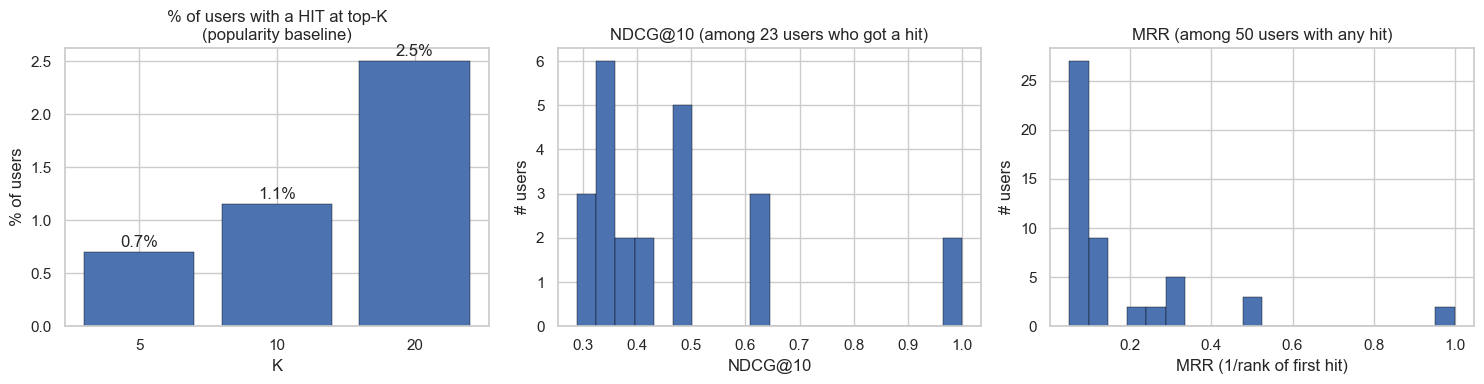


Takeaway: popularity gets a top-20 hit for ~2.5% of users. 
Week 2 models need to push this floor up substantially.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Recall@K is binary for most users (1 held-out → 0 or 1)
recall_dist = {k: sum(1 for v in per_user[f'recall@{k}'] if v > 0) for k in K_VALUES}
ax = axes[0]
ax.bar([str(k) for k in K_VALUES],
       [recall_dist[k]/len(eval_users)*100 for k in K_VALUES],
       edgecolor="black", linewidth=0.3)
ax.set_title("% of users with a HIT at top-K\n(popularity baseline)")
ax.set_xlabel("K"); ax.set_ylabel("% of users")
for k in K_VALUES:
    pct = recall_dist[k]/len(eval_users)*100
    ax.text(str(k), pct + 0.05, f"{pct:.1f}%", ha="center")

# NDCG@10 distribution among hitters
ndcg_hitters = [v for v in per_user["ndcg@10"] if v > 0]
ax = axes[1]
ax.hist(ndcg_hitters, bins=20, edgecolor="black", linewidth=0.3)
ax.set_title(f"NDCG@10 (among {len(ndcg_hitters)} users who got a hit)")
ax.set_xlabel("NDCG@10")
ax.set_ylabel("# users")

# MRR distribution among hitters
mrr_hitters = [v for v in per_user["mrr"] if v > 0]
ax = axes[2]
ax.hist(mrr_hitters, bins=20, edgecolor="black", linewidth=0.3)
ax.set_title(f"MRR (among {len(mrr_hitters)} users with any hit)")
ax.set_xlabel("MRR (1/rank of first hit)")
ax.set_ylabel("# users")

plt.tight_layout()
plt.show()
print(f"\nTakeaway: popularity gets a top-20 hit for ~{recall_dist[20]/len(eval_users)*100:.1f}% of users. ")
print(f"Week 2 models need to push this floor up substantially.")

## 5. Locked decisions cheat sheet

These are the decisions baked into the code. Full evidence and code references in [`docs/data_decisions.md`](../docs/data_decisions.md). When in doubt about *why* the code behaves a certain way, look there first.

| # | Decision | Default | Code reference |
|---|---|---|---|
| 1 | Training cohort | **authors' pre-split (24,961 active users / 681K interactions)** | `load_train_interactions()` |
| 1b | Evaluation | **dual-track: warm-item LOO + cold-item (authors' test)** | `time_based_split`, `load_test_interactions` |
| 2 | Drop 0-star ratings | True | `load_train_interactions(drop_zero_stars=True)` |
| 3 | Positive threshold | 4 stars | `POSITIVE_THRESHOLD = 4` |
| 4 | Track A split protocol | Leave-one-out by date, most recent positive | `time_based_split` |
| 5 | Stage 1 model menu | 8 models + SASRec stretch | `src/models/` |
| 6 | CF item filter | Recipes with ≥10 ratings (EASE, BPR, two-tower) | per-model `fit()` |
| 7a | Pantry — **reranker score** | `pantry_score()` non-staple overlap (continuous) | `src/utils/staples.py` |
| 7b | Pantry — **Useful Recall condition** | `missing_count() ≤ 3` non-staple items | `src/utils/staples.py` |
| 8 | Diet enforcement | Tag OR derived rule, AND ingredient blocklist | `src/reranker/diet.py` (W4) |
| 9 | Nutrition clipping | Calories ≤ 5000; PDV ≤ 1000% | `parse_nutrition` |
| 10 | Persona pantry size | **25-35 user-specific items** (staples are project-wide) | `data/personas/*.json` |
| 11 | Eval harness | Week 2 Day-1 deliverable; supports both tracks via `track=` | `src/eval/harness.py` (W2) |

### Three decisions worth re-emphasizing for Week 2 modelers

**Decision §1b — DUAL-TRACK EVALUATION:** the project evaluates Stage 1 models on **two complementary test sets**:
- **Track A (warm-item)**: standard CF benchmarking. Apply `time_based_split(load_train_interactions())` to get ~24K held-out positives where the model has seen the item via other users. Popularity floor = Recall@10 ≈ 3.0%. ALL 8 models compete here.
- **Track B (cold-item)**: use `load_test_interactions()` directly — the authors' published test set holds out items with 0 raters in train. Tests cold-item generalization. Only content-aware models (TF-IDF, Sentence-BERT, hybrid, two-tower) meaningfully compete; pure CF (popularity, MF, EASE, BPR) scores ~0 by construction.
- The story: hybrid is the only model that performs well on both tracks. The reranker improves Useful Recall on both.

**Decision §7 — staples-aware pantry, two metrics:** universal staples (salt, pepper, oil, flour, eggs, milk, butter, garlic, onion, etc.) are project-wide in `src/utils/staples.py`. The reranker uses `pantry_score()` (continuous, [0,1], measures non-staple overlap). Useful Recall uses `missing_count() ≤ 3` (count-based feasibility — "user only needs to buy 3 more things"). The reranker formula `final = s_diet × (αt·s_taste + αp·s_pantry + αn·s_nutrition)` is unchanged; only `s_diet` is a hard filter. Personas list only 25-35 user-specific items, not 40-60.

**Decision §6 — restrict EASE/BPR/two-tower to recipes with ≥10 ratings.** This is a memory constraint (full 226K × 226K matrix is ~200 GB; 20K × 20K is ~1.6 GB) and a signal-quality argument (recipes with <10 ratings are noise anyway). Recipes outside this pool get popularity fallback at inference time.

**Quick test** — try the new pre-split loaders interactively:
```python
from src.data.loader import load_prebuilt_split, load_train_interactions, load_test_interactions, time_based_split

# Track A — warm-item evaluation (preferred for CF benchmarking)
train_warm, test_warm = time_based_split(load_train_interactions(), holdout_per_user=1)
# train_warm: ~658K interactions, ~25K users
# test_warm: ~24K held-out positives (items have other raters in train)

# Track B — cold-item evaluation (authors' pre-split test)
test_cold = load_test_interactions()  # positives only by default
# 10,393 held-out positives, all on items with 0 raters in train
```

## 6. Convention summary — what every Week 2 model must do

If you're building one of the Stage 1 models (MF, EASE, BPR, content TF-IDF, Sentence-BERT, hybrid, two-tower):

1. **Inherit the interface**:
   ```python
   class YourModel:
       def fit(self, train_df: pd.DataFrame) -> "YourModel": ...
       def recommend(self, user_id: int, k: int = 10, exclude_seen: bool = True) -> list[int]: ...
   ```
   `train_df` will have columns `['user_id', 'recipe_id', 'date', 'rating', 'u', 'i']`. The `u`/`i` columns are the authors' remapped 0-indexed integers (useful for matrix-factorization implementations).

2. **Use the dual-track eval harness** (`src/eval/harness.py` — landing Week 2 Monday). Don't reimplement Recall@K or run your own loop over users. The harness supports both `track="warm"` (our LOO split) and `track="cold"` (authors' pre-split test).

3. **For memory-bound models (EASE, BPR, two-tower)**: filter `train_df` to recipes with ≥10 ratings inside your `fit()`. Record the recipe IDs you trained on; at recommend time, only score those items, then fall back to popularity for the rest.

4. **Content-aware models (TF-IDF, Sentence-BERT, two-tower, hybrid)** should also be able to score recipes OUTSIDE the train set — they read recipe metadata (ingredients, tags, name, nutrition) and can rank any recipe in `recipes_df`. This is what makes them work on the cold-item track.

5. **Be deterministic**. Seed any randomness (negative sampling, weight init, dropout). The harness will set numpy/torch seeds, but your model needs to honor them.

6. **Document each model's expected runtime in `docs/week2_progress.md`**. If your model takes 30 min to train, that's fine — say so.

7. **Beat popularity comfortably** on warm-track Recall@10. Floor numbers from the dual-track smoke test:
   - Warm Recall@10 = 3.00% (popularity baseline) — your model should beat this
   - Cold Recall@10 = 0.00% (popularity by construction can't do cold) — content-aware models should produce non-zero numbers
   - If your CF model isn't above the warm floor, debug before tuning.

## 7. Next: where to look

- **[`notebooks/week1_eda.ipynb`](week1_eda.ipynb)** — feasibility analysis per project pillar (Stage 1 CF density, rating-signal quality, pantry overlap, nutrition span, diet tag coverage, Useful Recall ceiling). Verdict table at the bottom.

- **[`docs/data_decisions.md`](../docs/data_decisions.md)** — full evidence and code references for each of the 11 locked decisions.

- **[`docs/week1_progress.md`](../docs/week1_progress.md)** — what got built, what's outstanding for the team (5 personas, 5 self-profiles, git remote setup, visual deck review).

- **[`docs/proposal_deck_rebuild_brief.md`](../docs/proposal_deck_rebuild_brief.md)** — the 591-line brief used to regenerate the proposal deck. Useful if you want to revisit slide content.

- **`PantryPlate_Proposal_v2.pptx`** — updated deck reflecting EDA findings (Slides 4, 6, 12 had load-bearing fixes).

### Week 2 lanes — pick one

Suggested affinities (from `data_decisions.md`):
- **Cornac/CF lane**: MF, EASE, BPR
- **Content/NLP lane**: TF-IDF, Sentence-BERT, hybrid linear
- **Deep learning (PyTorch) lane**: two-tower neural
- **Eval + analysis lane**: harness (Day 1 blocker), results aggregation, week2 progress note
- **Persona + demo + slides lane**: define generic personas, coordinate team self-profiles, slide updates